In [5]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib
import qRegNN as qrnn
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
from torchsummary import summary

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


In [6]:
additional_vars = ['jet1_pt','jet1_eta','jet1_phi','jet2_pt','jet2_eta','jet2_phi']
year=2017
print(year)
bkg,unnorm_bkg,mass_bkg,names = hf.LAPS_train("QCDBKG",year,num_batches=1,Mjj_cut=800,pt_cut=300,additional=additional_vars)
del bkg,unnorm_bkg,mass_bkg
data = np.load("QR_models/data.npy")
bkg = np.load("QR_models/bkg.npy")

2017


In [7]:
j1_varDict = {"pt":"jet1_pt",
              "eta":"jet1_eta",
              "phi":"jet1_phi",
              "m":r"$M_{j1}$",
              "tau21":r"Jet 1 $\tau_{21}$",
              "tau32":r"Jet 1 $\tau_{32}$",
              "tau43":r"Jet 1 $\tau_{43}$",
              "tauS":r"Jet 1 $\tau_s$",
              "pb":r"Jet 1 $P_b$",
              "npf":r"Jet 1 $n_{pf}$"}

j2_varDict = {"pt":"jet2_pt",
              "eta":"jet2_eta",
              "phi":"jet2_phi",
              "m":r"$M_{j2}$",
              "tau21":r"Jet 2 $\\tau_{21}$",
              "tau32":r"Jet 2 $\\tau_{32}$",
              "tau43":r"Jet 2 $\\tau_{43}$",
              "tauS":r"Jet 2 $\\tau_s$",
              "pb":r"Jet 2 $P_b$",
              "npf":r"Jet 2 $n_{pf}$"}

xlims = {
    "pt":[-2.5,10],
    "eta":[-2.5,2.5],
    "phi":[-2,2],
    "m":[-2,10],
    "tau21":[-3.5,3],
    "tau32":[-8,4],
    "tau43":[-10,6],
    "tauS":[-3,15],
    "pb":[-6,4],
    "npf":[-3,8]
}

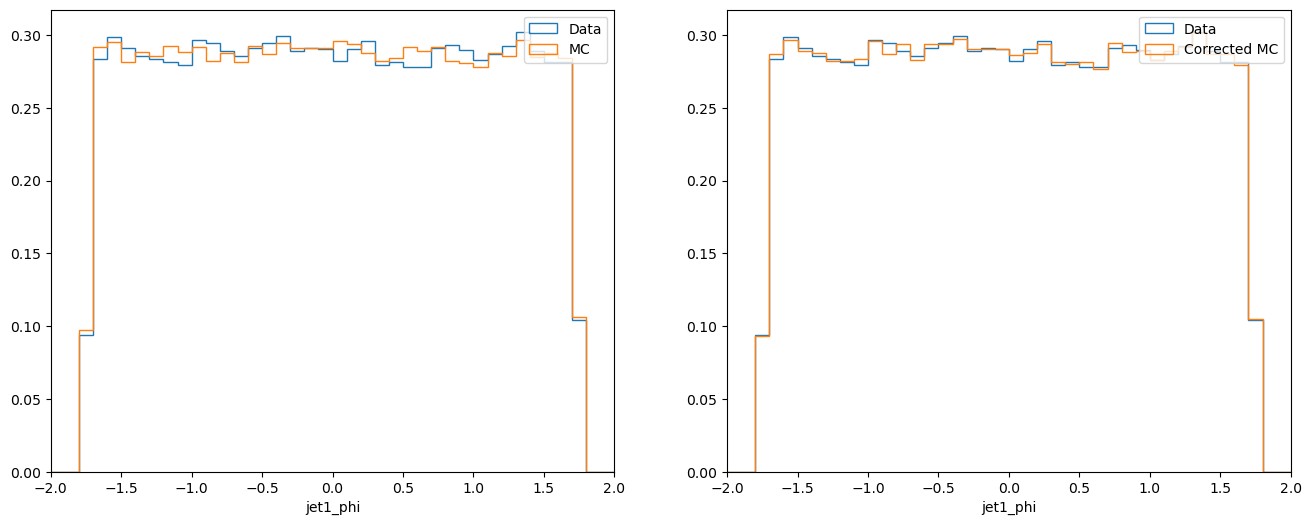

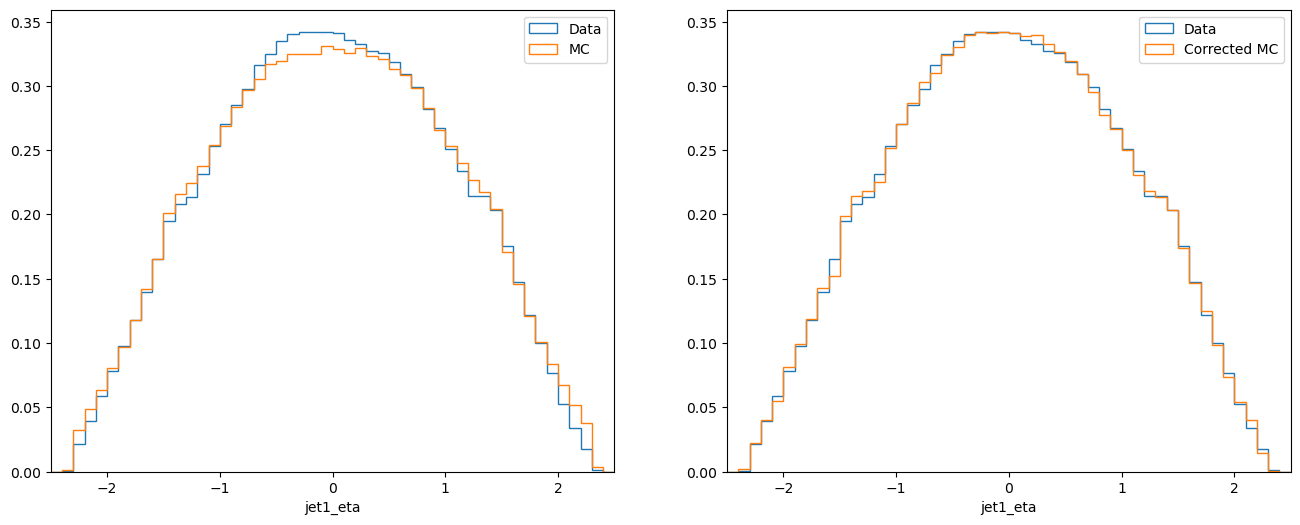

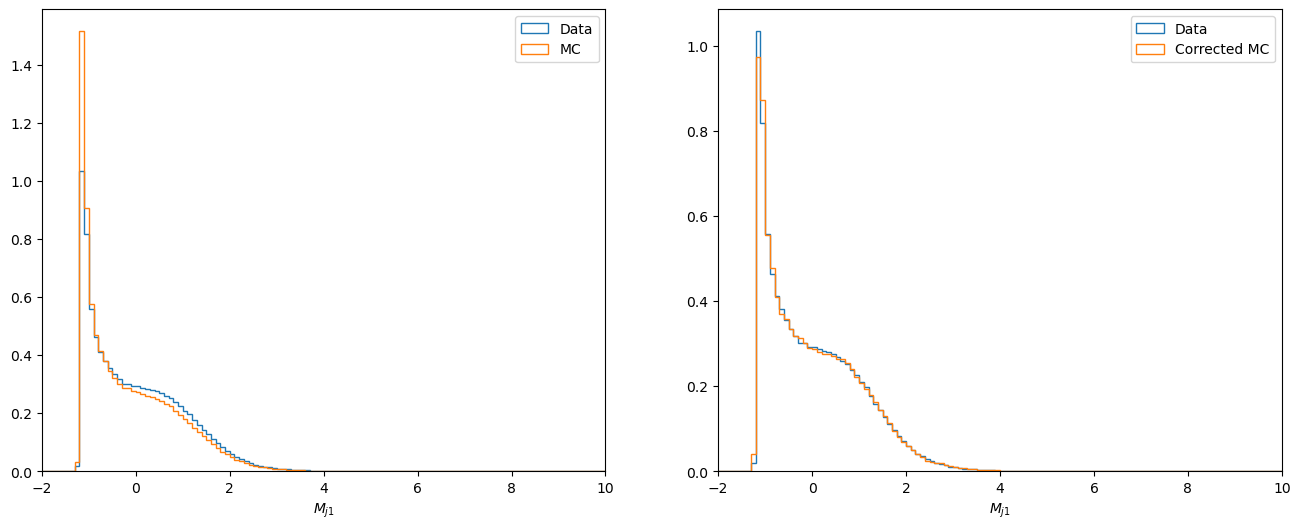

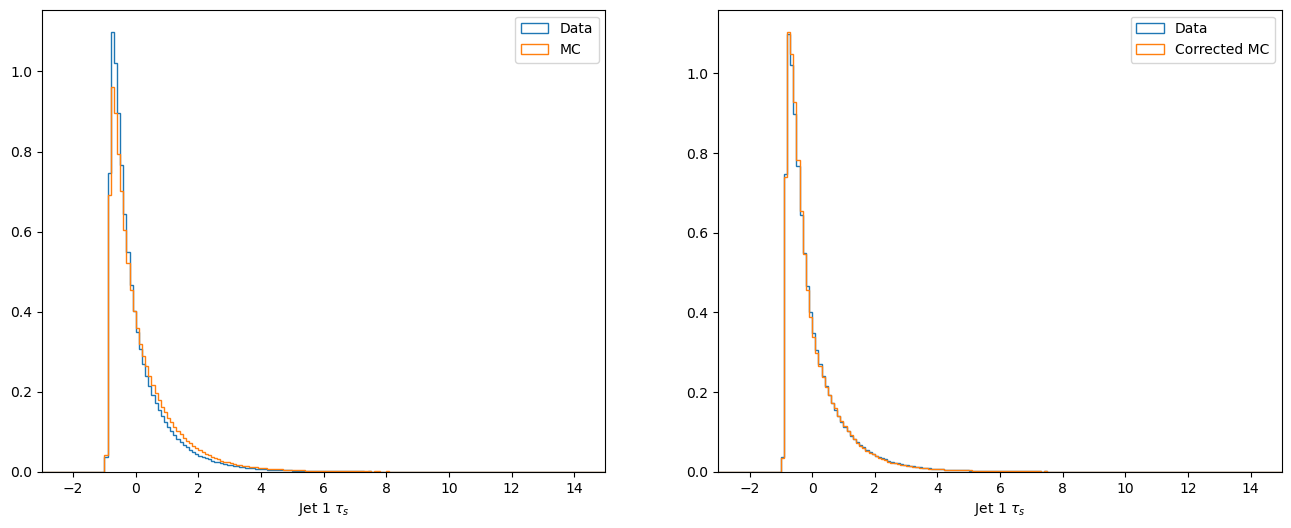

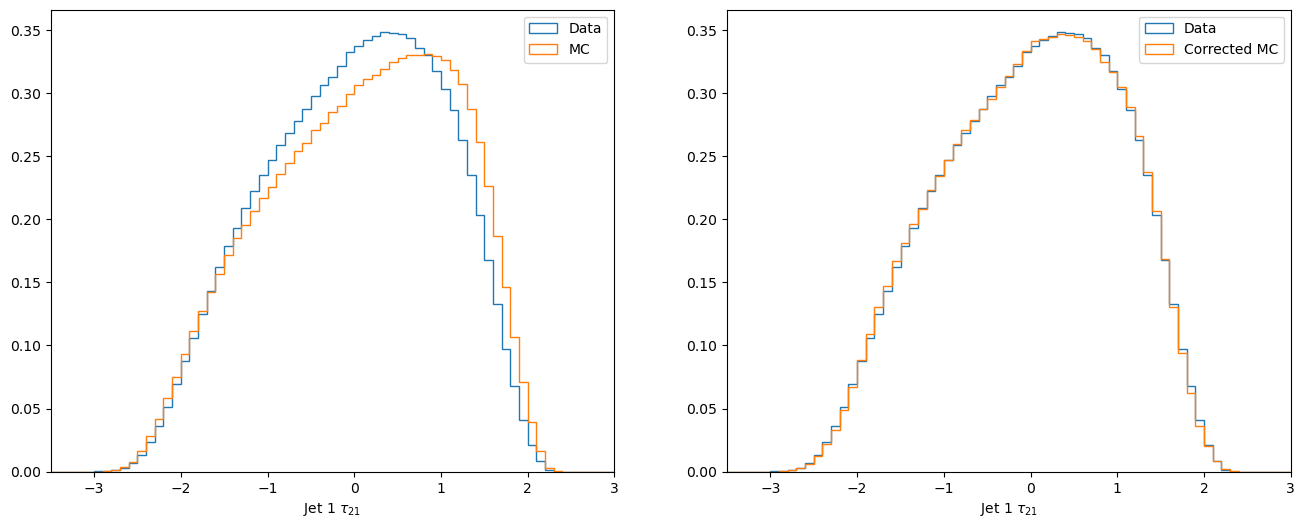

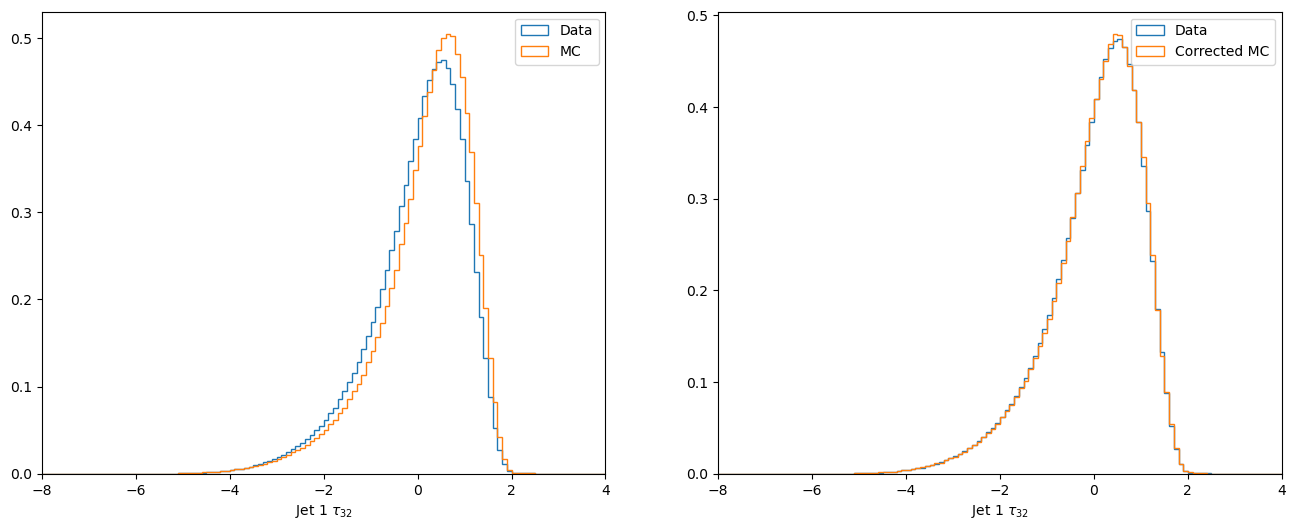

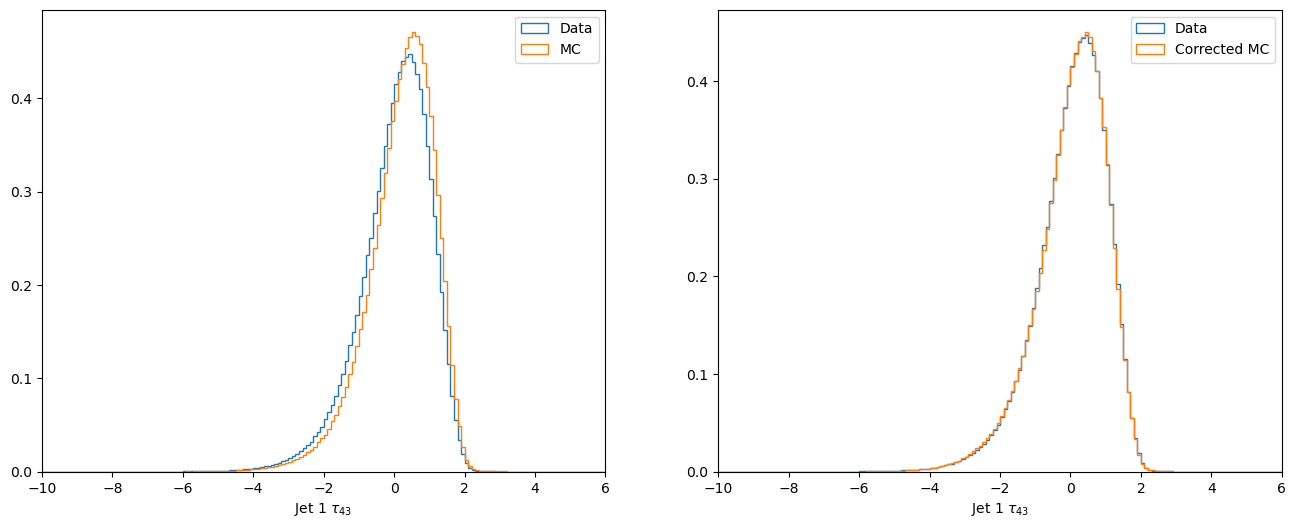

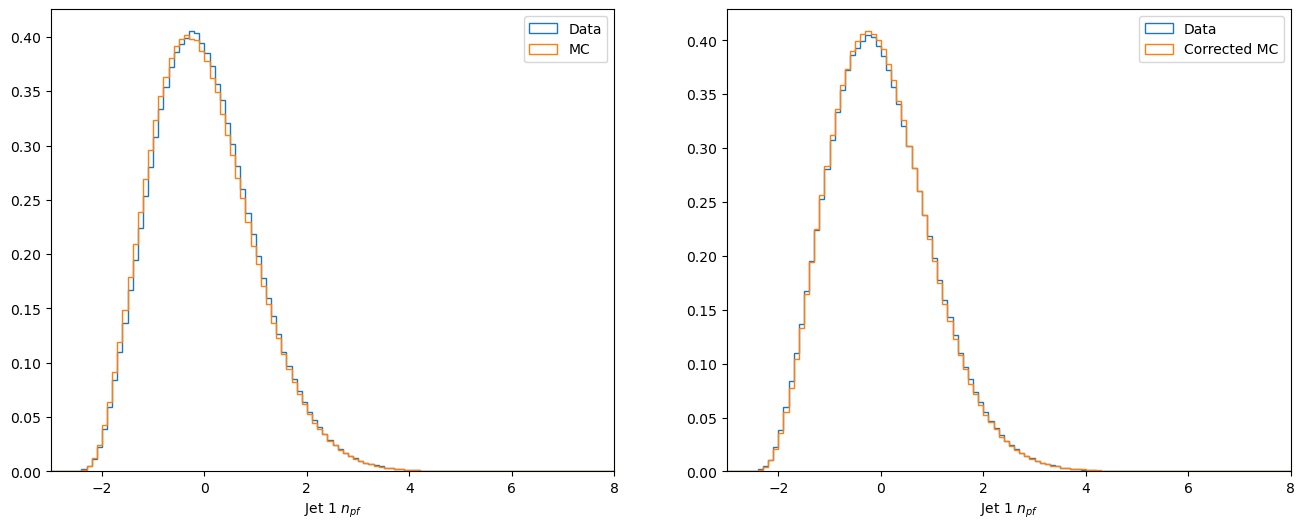

In [11]:
import os
baseDir = 'QR_models/jet1_correctors/'
order = ['phi','eta','m','tauS','tau21','tau32','tau43','npf']
for i,v in enumerate(order):
    idx = names.index(j1_varDict[v])
    d = data[:,idx]
    b = bkg[:,idx]
    file = baseDir+"corr_{0}_bkg_{1}.npy".format(i,v)
    bcorr = np.load(file)
    
    plt.figure(figsize=(16,6))
    bins = np.arange(-20,20.1,0.1)
    
    plt.subplot(121)
    h1 = plt.hist(d,bins=bins,histtype='step',density=True,label='Data')
    h2 = plt.hist(b,bins=bins,histtype='step',density=True,label='MC')
    plt.xlim(xlims[v])
    plt.xlabel(j1_varDict[v])
    plt.legend(loc='best')
    
    plt.subplot(122)
    h1 = plt.hist(d,bins=bins,histtype='step',density=True,label='Data')
    h2 = plt.hist(bcorr,bins=bins,histtype='step',density=True,label='Corrected MC')
    plt.xlim(xlims[v])
    plt.xlabel(j1_varDict[v])
    plt.legend(loc='best')
    
    plt.savefig(baseDir+"jet1_beforeAfter_{0}.pdf".format(v))

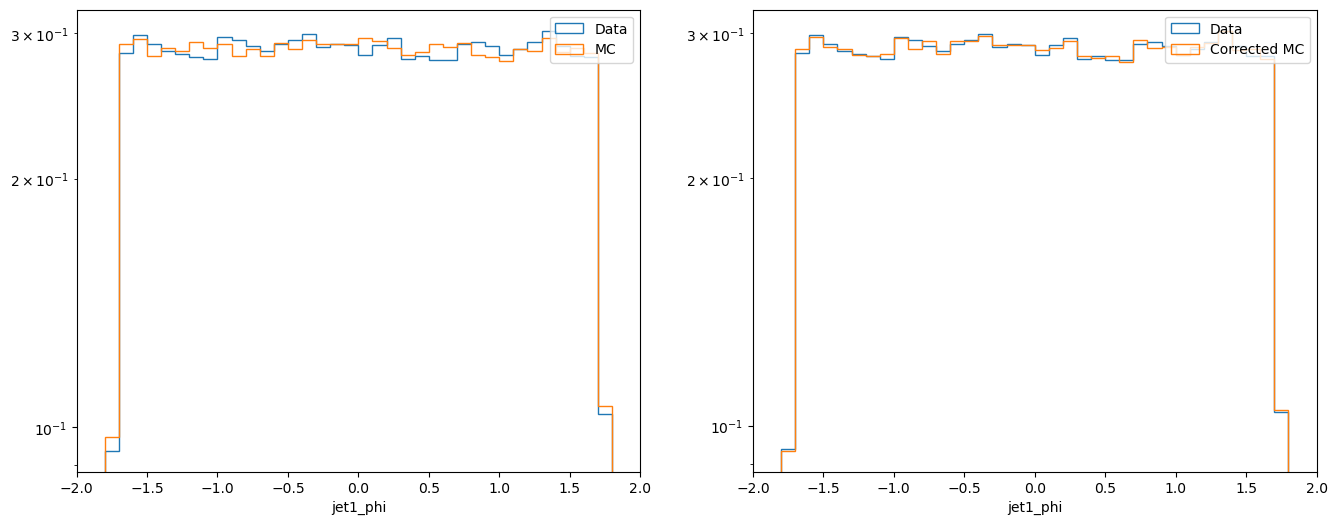

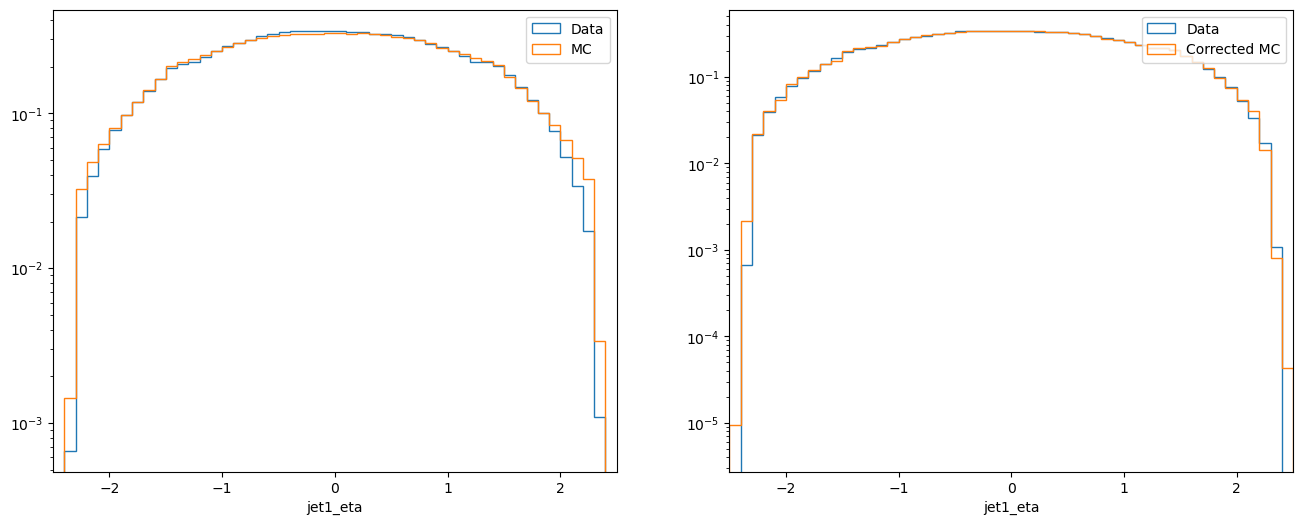

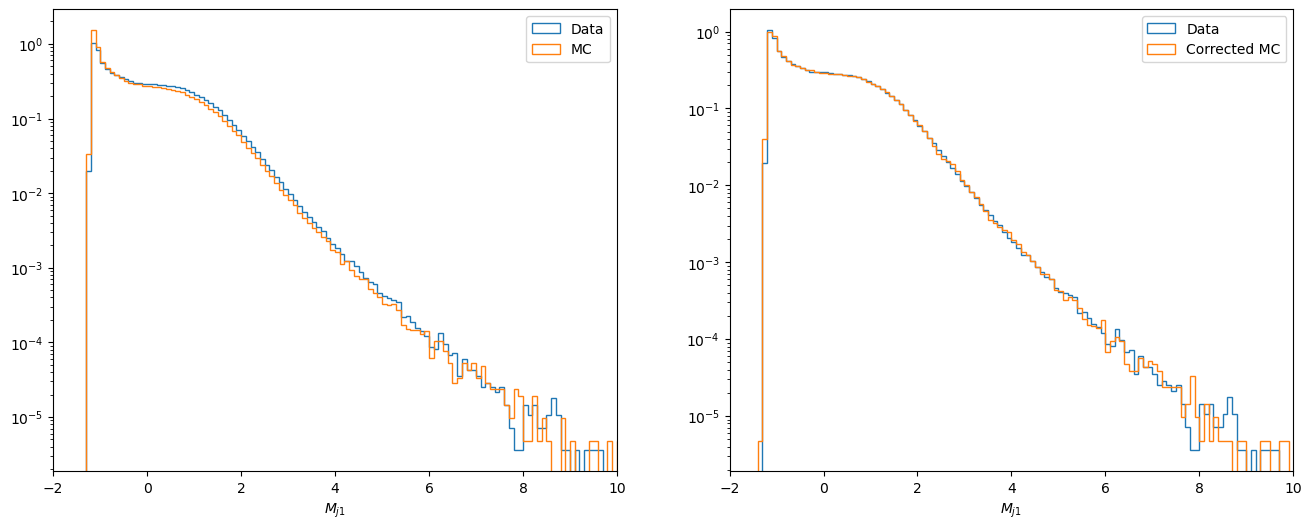

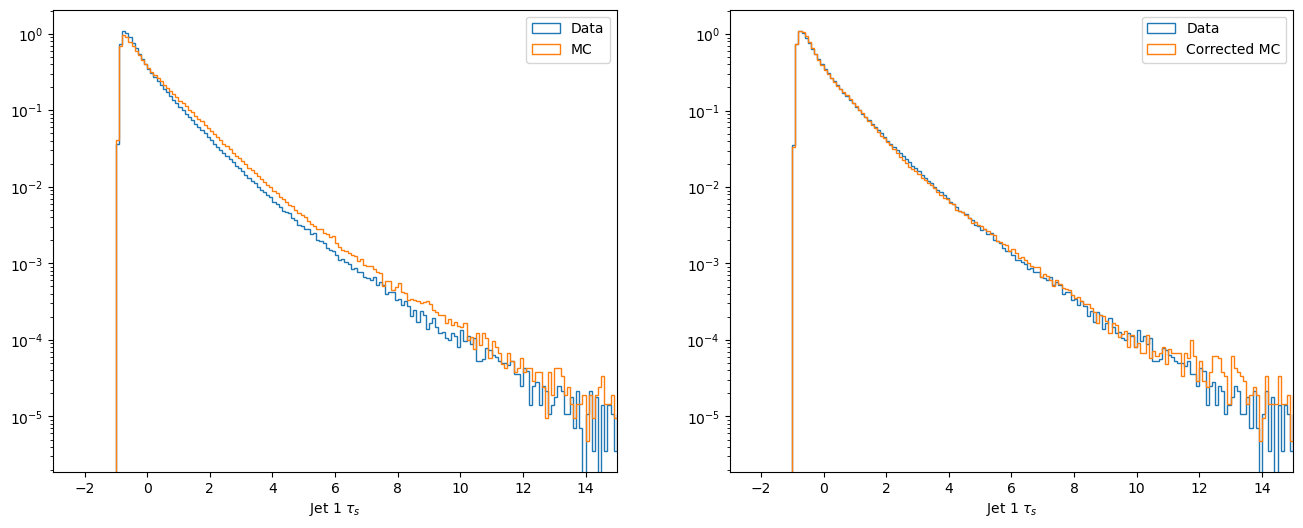

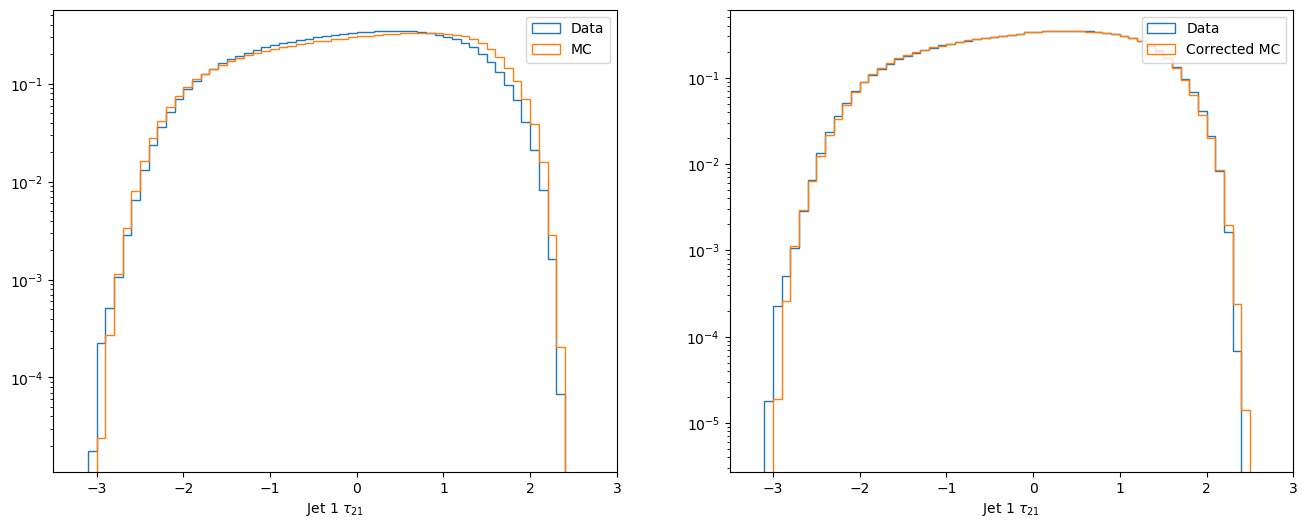

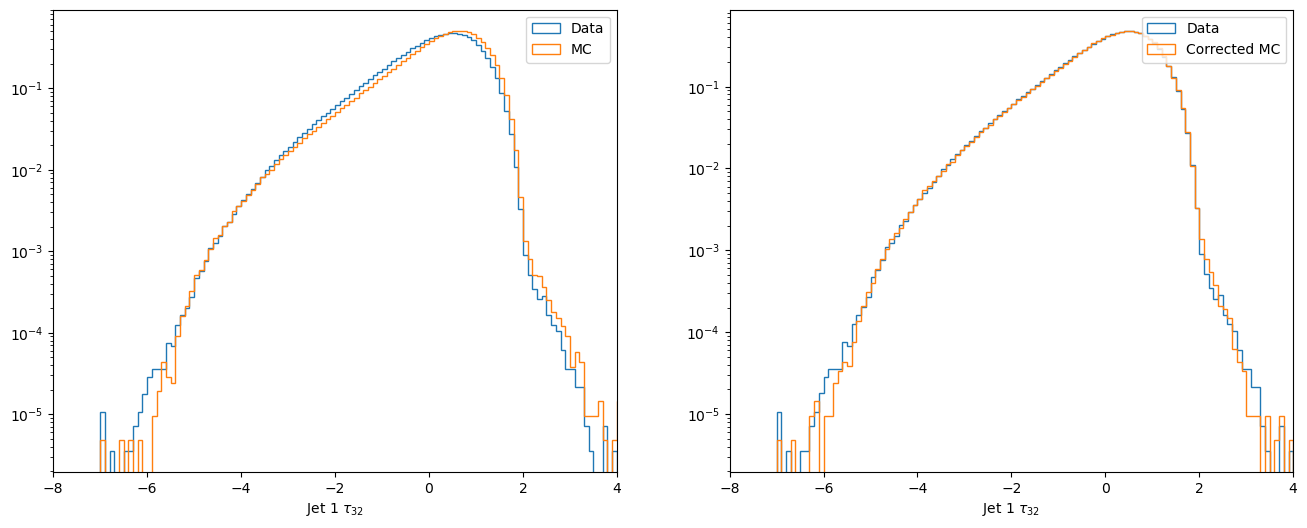

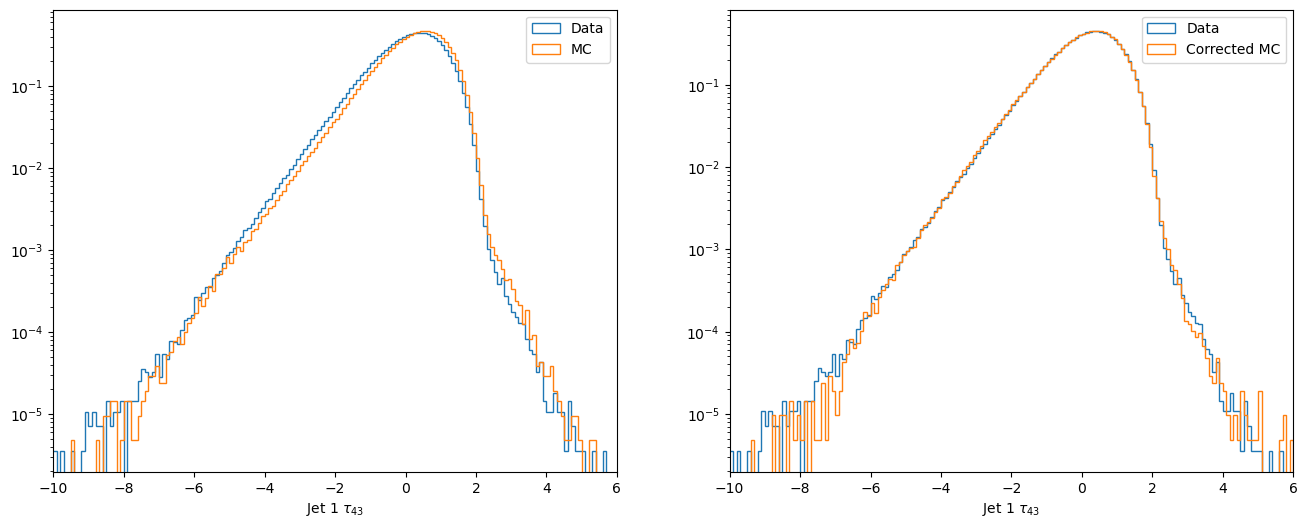

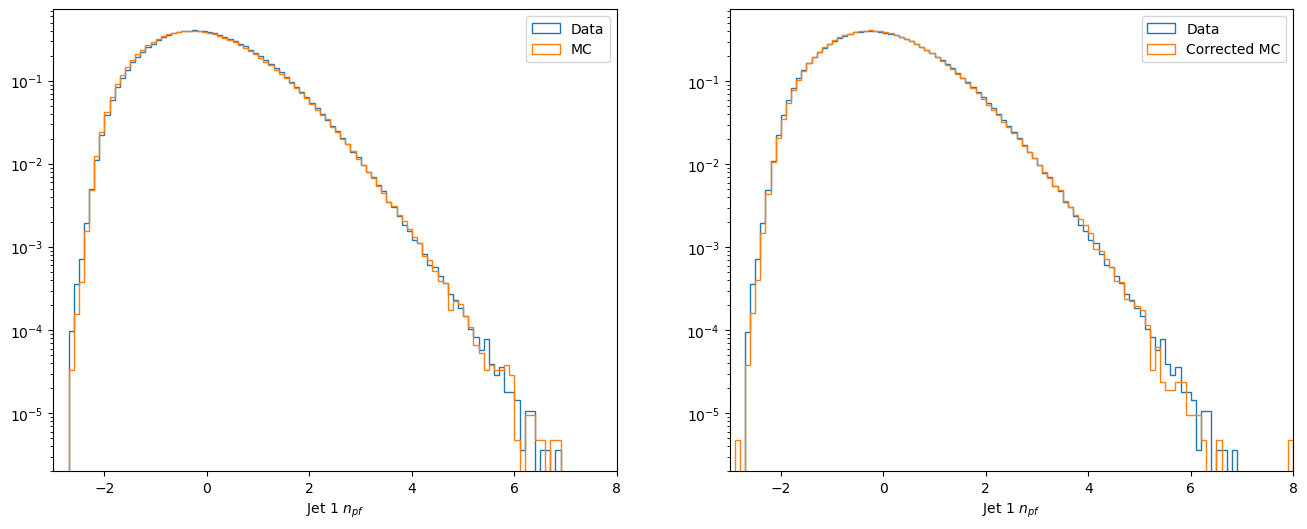

In [12]:
import os
baseDir = 'QR_models/jet1_correctors/'
order = ['phi','eta','m','tauS','tau21','tau32','tau43','npf']
for i,v in enumerate(order):
    idx = names.index(j1_varDict[v])
    d = data[:,idx]
    b = bkg[:,idx]
    file = baseDir+"corr_{0}_bkg_{1}.npy".format(i,v)
    bcorr = np.load(file)
    
    plt.figure(figsize=(16,6))
    bins = np.arange(-20,20.1,0.1)
    
    plt.subplot(121)
    h1 = plt.hist(d,bins=bins,histtype='step',density=True,label='Data')
    h2 = plt.hist(b,bins=bins,histtype='step',density=True,label='MC')
    plt.xlim(xlims[v])
    plt.xlabel(j1_varDict[v])
    plt.yscale('log')
    plt.legend(loc='best')
    
    plt.subplot(122)
    h1 = plt.hist(d,bins=bins,histtype='step',density=True,label='Data')
    h2 = plt.hist(bcorr,bins=bins,histtype='step',density=True,label='Corrected MC')
    plt.xlim(xlims[v])
    plt.xlabel(j1_varDict[v])
    plt.yscale('log')
    plt.legend(loc='best')
    
    plt.savefig(baseDir+"jet1_beforeAfter_{0}_log.pdf".format(v))

In [13]:
import torch

In [21]:
a = np.array([[1,2],[3,4]])
a

array([[1, 2],
       [3, 4]])

In [23]:
a.repeat(2,axis=0)

array([[1, 2],
       [1, 2],
       [3, 4],
       [3, 4]])

In [3]:
d = "evaluations/qcdbkg_massFlat/2017/quakSpaces/QCDBKG_massFlat_2017-Qstar2000_W400_UL17-and-Wp3000_B400_UL17-and-XYY_X3000_Y80_UL17/sigTrainQstar2000_W400_UL17-and-Wp3000_B400_UL17-and-XYY_X3000_Y80_UL17_bkgTrainQCDBKG/"
import os
import numpy as np
files = os.listdir(d)
bkg = [f for f in files if "QCDBKG" in f]
sig = [f for f in files if "QCDBKG" not in f]

nbkg = 0
for f in bkg:
    a = np.load(d+f)
    nbkg += a.shape[1]
    del a
print("there are {0} bkg events".format(nbkg))

for f in sig:
    a = np.load(d+f)
    print("file {0} has {1} events".format(f,a.shape[1]))
    del a

there are 2088603 bkg events
file eval_XYY_X3000_Y80_UL17.npy has 48620 events
file eval_Wp3000_B400_UL17.npy has 42608 events
file eval_Qstar2000_W400_UL17.npy has 35643 events


In [8]:
year=2017
bkg,unnorm_bkg,mass_bkg,names = hf.LAPS_train("QCDBKG",year,num_batches=-1,Mjj_cut=800,pt_cut=300)

In [9]:
bkg.shape

(2088603, 14)

In [10]:
sig,sig_unnorm,sig_mass,sig_names = hf.LAPS_train("XYY_X3000_Y80_UL17",year,num_batches=-1,Mjj_cut=800,pt_cut=300)

In [11]:
sig.shape

(48620, 14)

In [12]:
sig,sig_unnorm,sig_mass,sig_names = hf.LAPS_train("Wp3000_B400_UL17",year,num_batches=-1,Mjj_cut=800,pt_cut=300)

In [13]:
sig.shape

(42608, 14)

In [14]:
sig,sig_unnorm,sig_mass,sig_names = hf.LAPS_train("Qstar2000_W400_UL17",year,num_batches=-1,Mjj_cut=800,pt_cut=300)

In [15]:
d = "evaluations/qcdbkg_massFlat/2017/quakSpaces/QCDBKG_massFlat_2017-Qstar2000_W400_UL17-and-Wp3000_B400_UL17-and-XYY_X3000_Y80_UL17/sigTrainQstar2000_W400_UL17-and-Wp3000_B400_UL17-and-XYY_X3000_Y80_UL17_bkgTrainQCDBKG/test/"
import os
import numpy as np
files = os.listdir(d)
bkg = [f for f in files if "QCDBKG" in f]
sig = [f for f in files if "QCDBKG" not in f]

nbkg = 0
for f in bkg:
    a = np.load(d+f)
    nbkg += a.shape[1]
    del a
print("there are {0} bkg events".format(nbkg))

for f in sig:
    a = np.load(d+f)
    print("file {0} has {1} events".format(f,a.shape[1]))
    del a

there are 2088603 bkg events
file eval_XYY_X3000_Y80_UL17.npy has 48620 events
file eval_Wp3000_B400_UL17.npy has 42608 events
file eval_Qstar2000_W400_UL17.npy has 35643 events
